# 02_Model_Evaluation: Random Forest for Phishing Detection

This notebook evaluates the **Random Forest model** trained in `01_model_training.ipynb`.  
The trained model is loaded from the saved `RandomizedSearchCV` object, and the evaluation covers multiple aspects to ensure robustness and reliability.

**Model Evaluation steps:**
1. **Basic Model Outcome Evaluation**  
   - Evaluate model performance on the held-out test set (`X_test`, `y_test`)  
   - Compute metrics such as accuracy, precision, recall, F1-score, and confusion matrix

2. **Threshold Tuning**  
   - Adjust classification threshold for optimal precision-recall trade-off  
   - Analyze impact on model metrics

3. **Feature Importance Analysis**  
   - Visualize and interpret important features contributing to predictions  
   - Ensure insights align with domain knowledge

4. **Data Leakage Audit**  
   - Check for potential leakage between training and test data  
   - Verify that model performance is realistic and unbiased

5. **Sanity Baselines**  
   - Compare model against `DummyClassifier`
   - Confirm model performance is meaningfully better than naive predictions

6. **Save Final Model Pipeline**  
   - Save the trained pipeline along with metadata for future deployment or inference

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import os
import json

from joblib import dump, load
from sklearn import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

## Load Trained Model and Test Data

Load the **trained RandomizedSearchCV Random Forest model** saved from the training notebook.  

Also, load the **held-out train and test set** that was saved previously to ensure consistent evaluation.  

These will be used for all subsequent evaluation steps, including basic metrics, threshold tuning, and feature importance analysis.

In [2]:
rf_search = load("../models/rf_random_search.joblib")

X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

## Extract Best Pipeline and Make Predictions

Retrieve the **best estimator** from the `RandomizedSearchCV` object, which contains the Random Forest model trained with the optimal hyperparameters.  

Use this **best pipeline** to:
1. Generate **predictions (`y_pred`)** on the test set.
2. Compute **predicted probabilities (`y_proba`)** for threshold analysis.  

Additionally, inspect:
- `best_params_` to see the selected hyperparameters.
- `best_score_` to review the best cross-validated F1-score achieved during training.

In [3]:
best_pipeline = rf_search.best_estimator_
best_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",444
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If 

In [4]:
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

In [5]:
rf_search.best_params_

{'model__class_weight': 'balanced',
 'model__max_depth': None,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 444}

In [6]:
rf_search.best_score_

np.float64(0.9568951271170567)

## Confusion Matrix for Model Predictions

Visualize the model's **performance on the test set** using a confusion matrix.  

- `y_test` vs `y_pred` shows **true vs predicted labels** for phishing detection.  
- Display labels are set to `"Legitimate"` and `"Phishing"` for clarity.  
- The confusion matrix is plotted and saved to the `figures/` folder for future reference.  
- This provides a **quick overview of correct and incorrect predictions**, which is essential before performing further evaluation like threshold tuning or feature importance analysis.

In [7]:
def plot_confusion_matrix(y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Phishing"]
    )

    disp.plot(cmap="Blues")
    disp.ax_.set_title(title)
    plt.show()

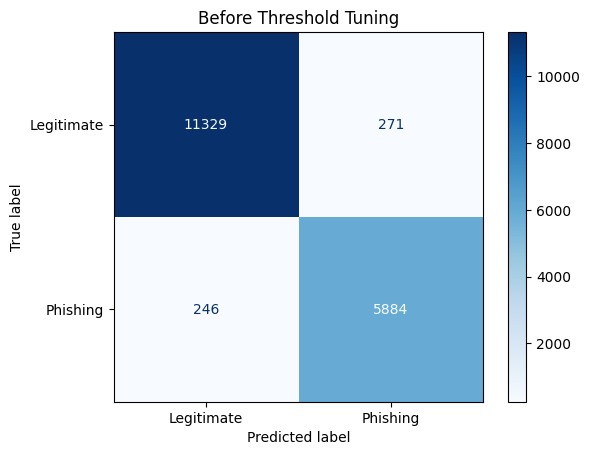

In [8]:
plot_confusion_matrix(y_pred, "Before Threshold Tuning")

In [9]:
plt.savefig("../figures/confusion_matrix_threshold_50.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Visualize Hyperparameter Search Results

Explore the outcomes of the **RandomizedSearchCV hyperparameter search** to understand how different hyperparameter combinations affected model performance.  

- Convert the `cv_results_` dictionary into a **DataFrame** for easier analysis.  
- Use a **scatter plot** to visualize the interaction between two hyperparameters (`max_depth` and `n_estimators`) and their effect on **mean cross-validated F1 score**.  
- This analysis helps identify **trends and patterns** in the hyperparameter space and can guide further tuning or interpretability.

In [9]:
cv_results = pd.DataFrame(rf_search.cv_results_)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__class_weight,param_model__max_depth,param_model__max_features,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,11.270940,0.388431,0.395283,0.017294,"{0: 1, 1: 2.0}",30,sqrt,3,9,288,"{'model__class_weight': {0: 1, 1: 2.0}, 'model...",0.947495,0.944939,0.939049,0.942786,0.946781,0.944210,0.003053,15
1,11.461945,0.174717,0.543213,0.030172,"{0: 1, 1: 1.6}",20,log2,3,8,430,"{'model__class_weight': {0: 1, 1: 1.6}, 'model...",0.937842,0.937958,0.929449,0.932937,0.938687,0.935375,0.003600,23
2,9.900971,0.509288,0.340482,0.030771,"{0: 1, 1: 1.2}",30,sqrt,4,9,251,"{'model__class_weight': {0: 1, 1: 1.2}, 'model...",0.945831,0.948443,0.940022,0.943686,0.948777,0.945352,0.003246,14
3,21.779826,9.325952,0.460392,0.149773,"{0: 1, 1: 1.2}",10,sqrt,2,9,393,"{'model__class_weight': {0: 1, 1: 1.2}, 'model...",0.931359,0.930986,0.923307,0.929889,0.931768,0.929462,0.003140,25
4,20.933134,6.127745,0.920849,0.446524,balanced,30,sqrt,1,7,352,"{'model__class_weight': 'balanced', 'model__ma...",0.956038,0.956460,0.948545,0.951306,0.955209,0.953512,0.003082,2


In [10]:
def plot_param_vs_score_scatter(cv_results, param_name, score_name="mean_test_score"):
    param_key = f"param_model__{param_name}"

    raw_x = cv_results[param_key]
    y = cv_results[score_name]

    x = []
    for v in raw_x:
        if v is None or str(v) == "None":
            x.append(0)
        else:
            x.append(float(v))

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y)
    plt.xlabel(param_name)
    plt.ylabel("Mean F1 Score")
    plt.title(f"Scatter Plot: {param_name} vs Mean F1 Score")
    plt.grid(True)

    ticks = sorted(set(x))
    labels = ["None" if t == 0 else str(int(t)) for t in ticks]
    plt.xticks(ticks, labels)

    plt.show()

def plot_param_vs_score_boxplot(cv_results, param_name, score_name="mean_test_score"):
    df = pd.DataFrame(cv_results)
    param_key = f"param_model__{param_name}"

    def stringify(v):
        if isinstance(v, dict):
            return f"{{0:1, 1:{v[1]:.2f}}}"
        return str(v)

    df[param_key] = df[param_key].apply(stringify)

    plt.figure(figsize=(7, 5))
    df.boxplot(
        column=score_name,
        by=param_key,
        grid=False
    )
    plt.xlabel(param_name)
    plt.ylabel("Mean F1 Score")
    plt.title(f"Boxplot: {param_name} vs Mean F1 Score")
    plt.suptitle("")
    plt.show()

def plot_n_estimators_scatter(cv_results):
    x = cv_results["param_model__n_estimators"].astype(int)
    y = cv_results["mean_test_score"]

    plt.figure(figsize=(12, 5))
    plt.scatter(x, y, alpha=0.5)
    plt.xlabel("n_estimators")
    plt.ylabel("Mean F1 Score")
    plt.title("Scatter Plot: n_estimators vs Mean F1 Score")
    plt.grid(True)
    plt.show()

def plot_class_weight_boxplot(cv_results):
    df = pd.DataFrame(cv_results)

    def stringify(v):
        if v is None:
            return "None"
        if v == "balanced":
            return "balanced"
        if isinstance(v, dict):
            return f"w={v[1]:.2f}"
        return str(v)

    df["class_weight"] = df["param_model__class_weight"].apply(stringify)

    plt.figure(figsize=(14, 6))
    df.boxplot(
        column="mean_test_score",
        by="class_weight",
        grid=False
    )
    plt.xlabel("class_weight (minority class weight)")
    plt.ylabel("Mean F1 Score")
    plt.title("Boxplot: class_weight vs Mean F1 Score")
    plt.suptitle("")
    plt.xticks(rotation=45)
    plt.show()

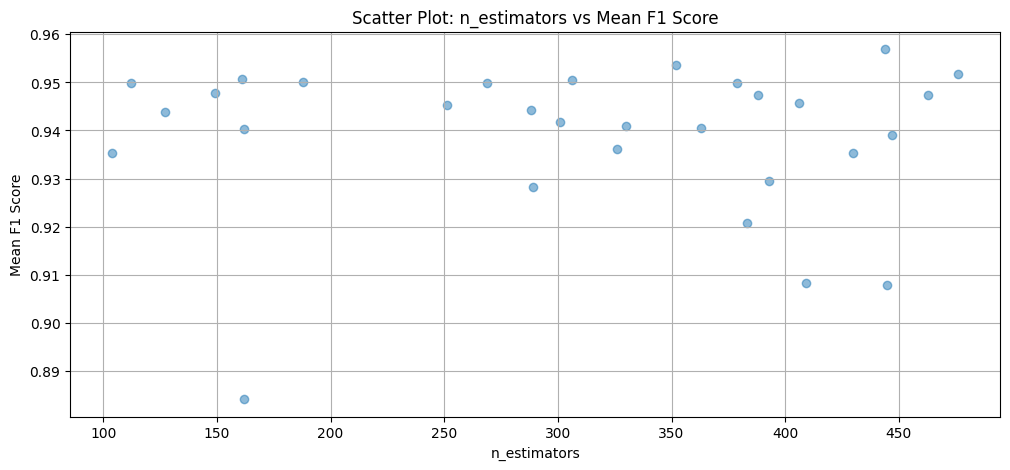

In [17]:
plot_n_estimators_scatter(cv_results)

In [18]:
plt.savefig("../figures/n_estimators_scatter.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

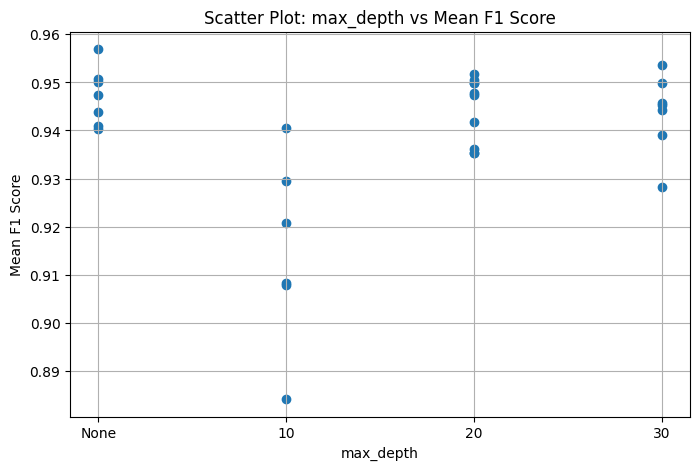

In [19]:
plot_param_vs_score_scatter(cv_results, "max_depth")

In [20]:
plt.savefig("../figures/max_depth_scatter.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

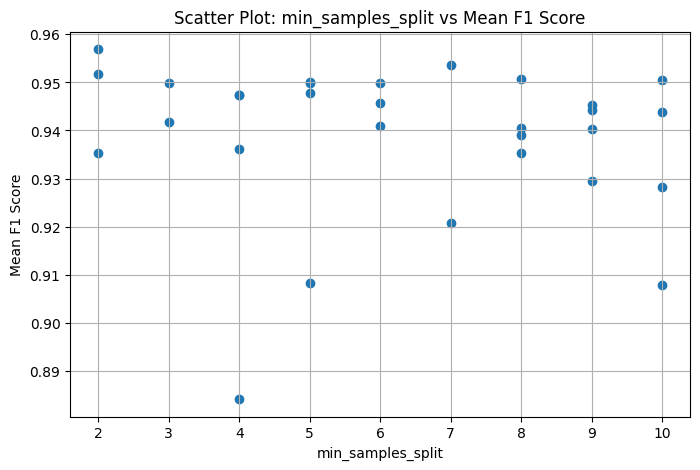

In [24]:
plot_param_vs_score_scatter(cv_results, "min_samples_split")

In [25]:
plt.savefig("../figures/min_samples_split_scatter.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

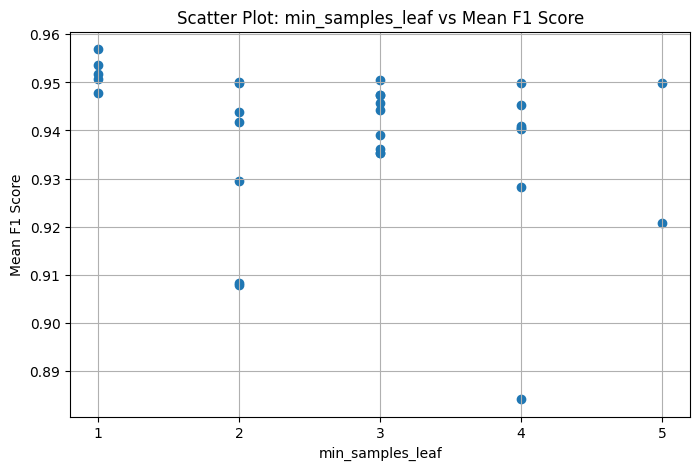

In [26]:
plot_param_vs_score_scatter(cv_results, "min_samples_leaf")

In [27]:
plt.savefig("../figures/min_samples_leaf_scatter.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

<Figure size 700x500 with 0 Axes>

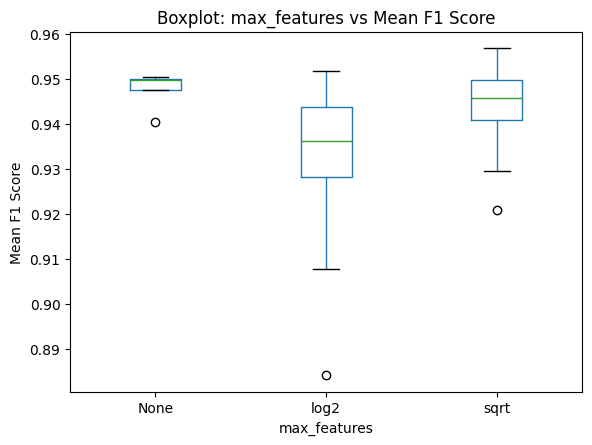

In [28]:
plot_param_vs_score_boxplot(cv_results, "max_features")

In [29]:
plt.savefig("../figures/max_features_boxplot.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

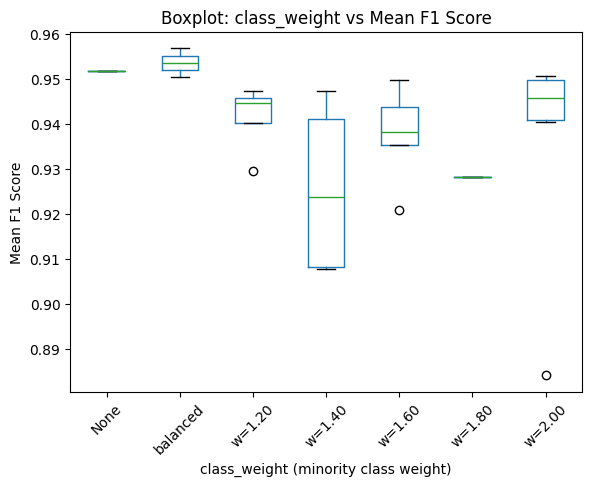

In [31]:
plot_class_weight_boxplot(cv_results)

In [32]:
plt.savefig("../figures/class_weight_boxplot.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Threshold Tuning for Classification

Explore how changing the **decision threshold** affects model performance for phishing detection.  

- Iterate through multiple threshold values between 0.1 and 0.9.  
- For each threshold, compute **precision, recall, and F1-score** on the test set.  
- Store results in a DataFrame for analysis.  
- Plot precision, recall, and F1-score against the threshold to visualize the **trade-offs**.  

This helps identify the **optimal threshold** that balances precision and recall according to the desired application (e.g., prioritizing catching phishing websites vs avoiding false positives).

In [33]:
def evaluate_thresholds(y_proba):
    threshold_results = []

    for t in np.linspace(0.1, 0.9, 17):
        y_pred_t = (y_proba >= t).astype(int)
        threshold_results.append({
            "threshold": t,
            "precision": precision_score(y_test, y_pred_t),
            "recall": recall_score(y_test, y_pred_t),
            "f1": f1_score(y_test, y_pred_t)
        })

    return pd.DataFrame(threshold_results)

def plot_threshold_tuning_curve(threshold_df, title="Threshold Tuning Curve"):
    plt.figure(figsize=(8, 5))
    plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
    plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [34]:
threshold_df = evaluate_thresholds(y_proba)
threshold_df

,threshold,precision,recall,f1
0,0.10,0.832172,0.993312,0.905630
1,0.15,0.865023,0.990049,0.923323
2,0.20,0.884942,0.987439,0.933385
3,0.25,0.900523,0.983524,0.940195
4,0.30,0.917392,0.980098,0.947709
5,0.35,0.929304,0.975693,0.951934
6,0.40,0.938428,0.969657,0.953787
7,0.45,0.947318,0.965090,0.956121
8,0.50,0.955660,0.959869,0.957760
9,0.55,0.962621,0.953670,0.958125


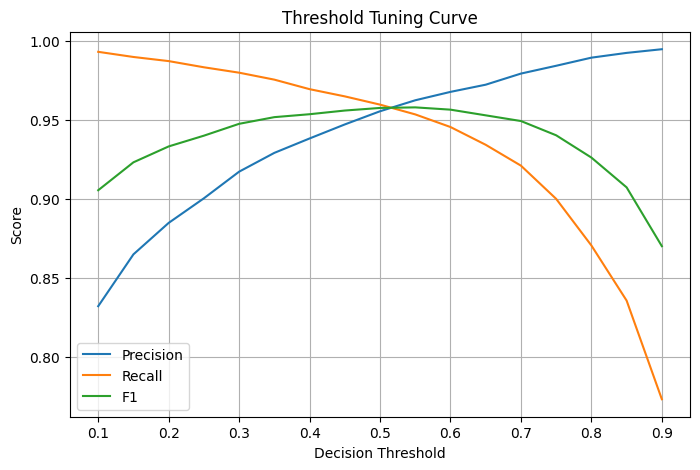

In [35]:
plot_threshold_tuning_curve(threshold_df)

In [21]:
plt.savefig("../figures/threshold_tuning_curve.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Confusion Matrix at Custom Decision Threshold

Visualize the model's predictions using a **custom decision threshold** chosen from the threshold tuning analysis.  

- Convert predicted probabilities (`y_proba`) to binary predictions (`y_pred`) using the selected threshold.  
- Compute the **confusion matrix** to compare true vs predicted labels.  
- Display labels as `"Legitimate"` and `"Phishing"` for clarity.  
- Plot and save the confusion matrix to the `figures/` folder for documentation and reporting purposes.  

This allows evaluation of how changing the threshold affects **false positives and false negatives** in the phishing detection task.

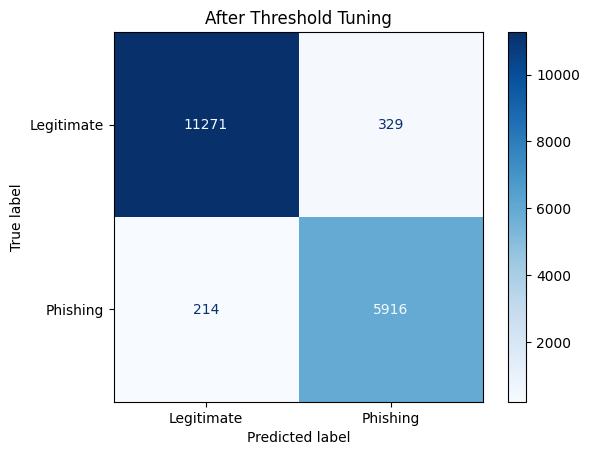

In [36]:
threshold = 0.45

y_pred = (y_proba >= threshold).astype(int)
plot_confusion_matrix(y_pred, "After Threshold Tuning")

In [23]:
plt.savefig("../figures/confusion_matrix_threshold_45.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Feature Importance Analysis

Evaluate which features contribute most to the Random Forest model's predictions using two complementary methods:

1. **Mean Decrease in Impurity (MDI)**  
   - Extract feature importances from the trained Random Forest (`feature_importances_`).  
   - Rank features by their contribution to reducing node impurity during training.  
   - Provides a quick overview of the most influential features.

2. **Permutation Importance**  
   - Measure the change in **F1-score** when each feature's values are randomly shuffled.  
   - Compute mean and standard deviation over multiple repeats to assess feature stability.  
   - Helps confirm which features truly impact model performance on the test set.  

The results are stored in DataFrames (`impurity_df` and `perm_df`) and can be further visualized to interpret model behavior.

In [37]:
importances = best_pipeline.named_steps["model"].feature_importances_
feature_names = X_train.columns

impurity_df = (
    pd.DataFrame({
        "feature": feature_names,
        "impurity_importance": importances
    })
    .sort_values("impurity_importance", ascending=False)
)
impurity_df

,feature,impurity_importance
100,time_domain_activation,0.058753
57,directory_length,0.054501
3,qty_slash_url,0.031561
18,length_url,0.028932
69,qty_comma_file,0.027037
...,...,...
26,qty_and_domain,0.000000
27,qty_exclamation_domain,0.000000
28,qty_space_domain,0.000000
29,qty_tilde_domain,0.000000


In [26]:
r = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    scoring="f1",
    random_state=42,
    n_jobs=1
)

perm_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "perm_mean": r.importances_mean,
        "perm_std": r.importances_std
    })
    .sort_values("perm_mean", ascending=False)
)
perm_df

KeyboardInterrupt: 

In [ ]:
dump(perm_df, "../outputs/feature_importance/permutation_importance.joblib")

['../models/permutation_importance.joblib']

## Feature Reduction and Training a Reduced-Feature Random Forest

Perform **feature selection** to remove uninformative or redundant features and retrain the model on the **reduced feature set**.  

- Combine **impurity-based importance** (`impurity_df`) and **permutation importance** (`perm_df`) into a single DataFrame (`importance_df`).  
- Identify features to drop based on the following criteria:  
  - Permutation importance (`perm_mean`) is ≤ 0, or  
  - Both impurity importance and absolute permutation importance are below small thresholds (`IMPURITY_EPS`, `PERM_EPS`).  
- Split features into `features_to_drop` and `features_to_keep`.  
- Create reduced training and test sets (`X_train_reduced`, `X_test_reduced`) by dropping the uninformative features.  
- Train a **new Random Forest** (`rf_reduced`) on the reduced feature set.  
- Predict both labels (`y_pred_reduced`) and probabilities (`y_proba_reduced`) on the test set for downstream evaluation.  

This step improves model efficiency, reduces overfitting risk, and prepares the dataset for the **Data Leakage Audit** and threshold tuning analysis.

In [39]:
importance_df = impurity_df.merge(perm_df, on="feature")
importance_df

,feature,impurity_importance,perm_mean,perm_std
0,time_domain_activation,0.058753,0.056972,0.001399
1,directory_length,0.054501,0.010765,0.001130
2,qty_slash_url,0.031561,0.001220,0.000348
3,length_url,0.028932,0.005363,0.000713
4,qty_comma_file,0.027037,-0.000479,0.000158
...,...,...,...,...
106,qty_and_domain,0.000000,0.000000,0.000000
107,qty_exclamation_domain,0.000000,0.000000,0.000000
108,qty_space_domain,0.000000,0.000000,0.000000
109,qty_tilde_domain,0.000000,0.000000,0.000000


In [40]:
IMPURITY_EPS = 1e-6
PERM_EPS = 1e-6

importance_df["drop_feature"] = (
    (importance_df["perm_mean"] <= 0) |
    (
        (importance_df["impurity_importance"] <= IMPURITY_EPS) &
        (importance_df["perm_mean"].abs() <= PERM_EPS)
    )
)

In [41]:
features_to_drop = importance_df.loc[
    importance_df["drop_feature"], "feature"
].tolist()

features_to_keep = importance_df.loc[
    ~importance_df["drop_feature"], "feature"
].tolist()

In [42]:
print(f"Features before: {X_train.shape[1]}")
print(f"Features dropped: {len(features_to_drop)}")
print(f"Features remaining: {len(features_to_keep)}")

Features before: 111
Features dropped: 78
Features remaining: 33


In [43]:
X_train_reduced = X_train.drop(columns=features_to_drop)
X_test_reduced = X_test.drop(columns=features_to_drop)

In [44]:
rf_reduced = RandomForestClassifier(**best_pipeline.named_steps["model"].get_params())
rf_reduced.fit(X_train_reduced, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",444
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
y_pred_reduced = rf_reduced.predict(X_test_reduced)
y_proba_reduced = rf_reduced.predict_proba(X_test_reduced)[:, 1]

## Confusion Matrix for Reduced Feature Set

Visualize the model's performance using a **reduced set of features** before applying any threshold tuning.  

- `y_pred_reduced` contains predictions made by the Random Forest trained on the reduced feature set.  
- Plotting the **confusion matrix** provides insight into the number of **true positives, false positives, true negatives, and false negatives**.  
- This helps assess how feature reduction affects the model's ability to distinguish between `"Legitimate"` and `"Phishing"` classes.

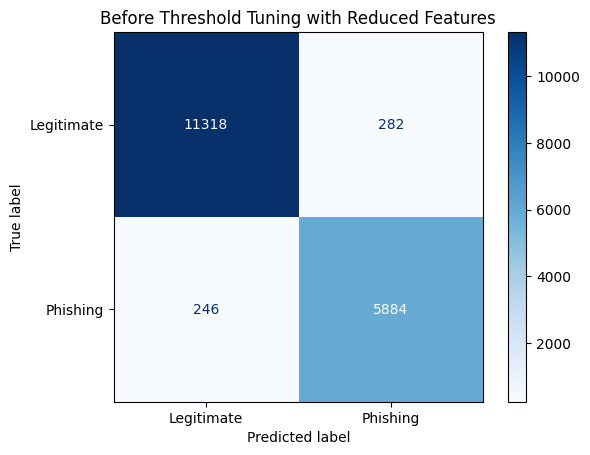

In [46]:
plot_confusion_matrix(y_pred_reduced, "Before Threshold Tuning with Reduced Features")

In [41]:
plt.savefig("../figures/confusion_matrix_threshold_50_reduced.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Threshold Tuning for Reduced Feature Set

Analyze how changing the **decision threshold** affects model performance when using a **reduced set of features**.  

- `evaluate_thresholds` computes **precision, recall, and F1-score** across a range of thresholds for the predictions (`y_proba_reduced`).  
- The resulting DataFrame (`threshold_reduced_df`) summarizes the scores for each threshold.  
- `plot_threshold_tuning_curve` visualizes these metrics to identify the **optimal threshold** for balancing precision and recall.  
- This step allows comparison of **threshold effects** between the full feature set and reduced feature set.

In [47]:
threshold_reduced_df = evaluate_thresholds(y_proba_reduced)
threshold_reduced_df

,threshold,precision,recall,f1
0,0.10,0.840840,0.992822,0.910533
1,0.15,0.870214,0.989886,0.926200
2,0.20,0.889395,0.986460,0.935417
3,0.25,0.904068,0.982382,0.941600
4,0.30,0.920706,0.979282,0.949091
5,0.35,0.930573,0.975204,0.952366
6,0.40,0.939356,0.970310,0.954582
7,0.45,0.948229,0.965090,0.956585
8,0.50,0.953956,0.959869,0.956904
9,0.55,0.962311,0.953834,0.958053


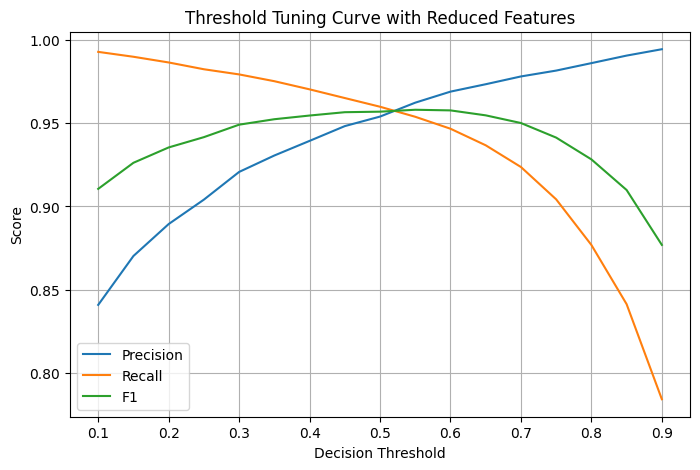

In [48]:
plot_threshold_tuning_curve(threshold_reduced_df, "Threshold Tuning Curve with Reduced Features")

In [44]:
plt.savefig("../figures/threshold_tuning_curve_reduced.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Confusion Matrix After Threshold Tuning (Reduced Feature Set)

Visualize the model's predictions **after applying the selected decision threshold** for the reduced feature set.  

- `y_pred_reduced` contains predictions converted from probabilities (`y_proba_reduced`) using the optimal threshold.  
- Plotting the confusion matrix allows comparison of **true positives, false positives, true negatives, and false negatives** after threshold tuning.  
- This helps evaluate whether reducing features affects the model's ability to correctly classify `"Legitimate"` and `"Phishing"` samples after threshold adjustments.

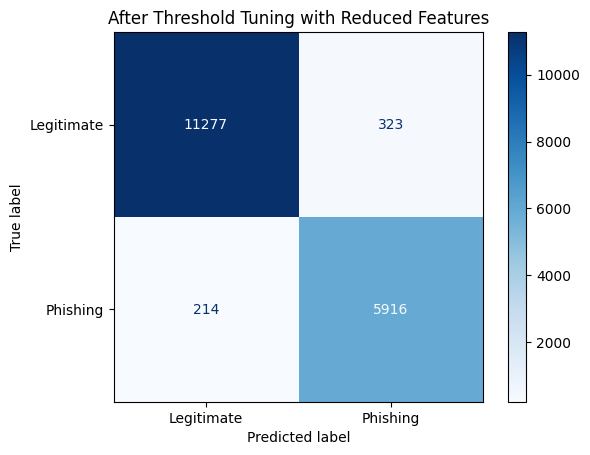

In [49]:
y_pred_reduced = (y_proba_reduced >= threshold).astype(int)
plot_confusion_matrix(y_pred_reduced, "After Threshold Tuning with Reduced Features")

In [46]:
plt.savefig("../figures/confusion_matrix_threshold_45_reduced.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Data Leakage Audit – Manual Feature Inspection

Before training the model, perform a **manual review of features** to identify any that could potentially lead to **data leakage**.  

- Start by listing all features in the training set (`X_train_reduced`).  
- For each feature, ask questions like:  
  - Could this feature contain information derived from the target (`phishing`)?  
  - Could this feature only be available **after the event** we are trying to predict?  
- Features that could leak information about the target should be **removed or modified** before model training.  

This step ensures that the model's predictive performance is **trustworthy and not artificially inflated** by features that indirectly contain the target information.

In [50]:
list(X_train_reduced.columns)

['qty_dot_url',
 'qty_hyphen_url',
 'qty_slash_url',
 'qty_at_url',
 'qty_percent_url',
 'qty_tld_url',
 'length_url',
 'qty_dot_domain',
 'qty_hyphen_domain',
 'qty_vowels_domain',
 'domain_length',
 'server_client_domain',
 'qty_dot_directory',
 'qty_hyphen_directory',
 'qty_slash_directory',
 'directory_length',
 'qty_dot_file',
 'file_length',
 'qty_questionmark_params',
 'params_length',
 'tld_present_params',
 'email_in_url',
 'time_response',
 'domain_spf',
 'asn_ip',
 'time_domain_activation',
 'time_domain_expiration',
 'qty_ip_resolved',
 'qty_nameservers',
 'qty_mx_servers',
 'ttl_hostname',
 'tls_ssl_certificate',
 'qty_redirects']

## Data Leakage Audit – Label Shuffling Test

After manually reviewing features, perform a **sanity check using label shuffling** to detect potential data leakage:  

1. **Shuffle the target labels** (`y_train`) randomly while keeping the features unchanged.  
2. Fit a **Random Forest pipeline** on the training data with shuffled labels.  
3. Predict probabilities on the test set and compute the **AUC score**.  
4. Repeat this process multiple times (e.g., 10 runs) to obtain a distribution of AUC scores under random labels.  
5. Compute the **mean and standard deviation** of these AUC scores.  

**Interpretation:**  
- If the model still achieves high AUC on shuffled labels, it may indicate **hidden data leakage**.  
- If the mean AUC is near **0.5**, the model is **not learning from leaked information**, confirming the integrity of the features.  

Finally, save the results to a JSON file (`label_shuffling_rf_reduced.json`) for reproducibility and documentation using `save_label_shuffling_result`.

In [82]:
def evaluate_auc(pipeline, X_train, y_train, X_test, y_test):
    aucs = []

    for _ in range(10):
        y_shuffled = np.random.permutation(y_train)
        rf_tmp = clone(pipeline)
        rf_tmp.fit(X_train, y_shuffled)

        y_proba = rf_tmp.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, y_proba))

    return aucs

In [ ]:
aucs = evaluate_auc(rf_reduced, X_train_reduced, y_train, X_test_reduced, y_test)
mean_reduced = float(np.mean(aucs))
std_reduced = float(np.std(aucs))

0.4915752404792709
0.007888074973829057


In [ ]:
print(aucs)
print(mean_reduced)
print(std_reduced)

In [ ]:
def save_label_shuffling_result(
    filename,
    model_name,
    description,
    mean_score,
    std_score,
    n_runs,
    metric="AUC",
    aucs=None
):
    result = {
        "model_name": model_name,
        "description": description,
        "test_type": "label_shuffling",
        "n_runs": n_runs,
        "metric": metric,
        "mean_score": mean_score,
        "std_score": std_score,
        "expected_behavior": "Approximately random (≈ 0.5)",
        "passed": abs(mean_score - 0.5) < 0.05
    }

    if aucs is not None:
        result["individual_scores"] = aucs

    full_path = os.path.join("..", "outputs", "data_leakage_audit", filename)

    with open(full_path, "w") as f:
        json.dump(result, f, indent=4)

In [ ]:
save_label_shuffling_result(
    "label_shuffling_rf_reduced.json",
    "rf_reduced",
    "Reduced-feature model before leakage feature removal",
    mean_reduced,
    std_reduced,
    n_runs=10,
    aucs=aucs
)

## Training a Leakage-Safe Random Forest Model

After identifying features that could potentially lead to **data leakage**, we remove these features from the dataset and retrain the model to ensure a robust and trustworthy evaluation.  

- **Leakage features removed**: `time_response`, `time_domain_activation`, `time_domain_expiration`, `qty_redirects`.  
- Create a new training and test set (`X_train_safe`, `X_test_safe`) without the leakage features.  
- Initialize a **new Random Forest** using the same hyperparameters from the best pipeline.  
- Fit the model on the **leakage-safe training set**.  
- Predict both labels (`y_pred_safe`) and probabilities (`y_proba_safe`) on the test set for downstream evaluation.  

This step ensures that the model's performance is **not artificially inflated** by features that indirectly contain target information.

In [51]:
leakage_features = [
    "time_response",
    "time_domain_activation",
    "time_domain_expiration",
    "qty_redirects",
]

importance_df_leakage = importance_df[
    importance_df["feature"].isin(leakage_features)
].copy()

importance_df_leakage

,feature,impurity_importance,perm_mean,perm_std,drop_feature
0,time_domain_activation,0.058753,0.056972,0.001399,False
16,time_response,0.021535,0.003916,0.000589,False
18,time_domain_expiration,0.021114,0.004112,0.000487,False
49,qty_redirects,0.007269,0.002235,0.000378,False


In [52]:
X_train_safe = X_train_reduced.drop(columns=leakage_features)
X_test_safe = X_test_reduced.drop(columns=leakage_features)

In [53]:
rf_safe = RandomForestClassifier(**best_pipeline.named_steps["model"].get_params())
rf_safe.fit(X_train_safe, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",444
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [54]:
y_pred_safe = rf_safe.predict(X_test_safe)
y_proba_safe = rf_safe.predict_proba(X_test_safe)[:, 1]

## Confusion Matrix for Reduced Leakage-Safe Feature Set

Visualize the model's performance using the **reduced set of leakage-safe features** before applying threshold tuning.  

- `y_pred_safe` contains predictions made by the Random Forest trained on the **leakage-safe reduced feature set**.  
- Plotting the confusion matrix shows **true positives, false positives, true negatives, and false negatives**.  
- This helps assess the model's predictive ability when potentially leaky features are removed, providing a **more robust and trustworthy evaluation**.

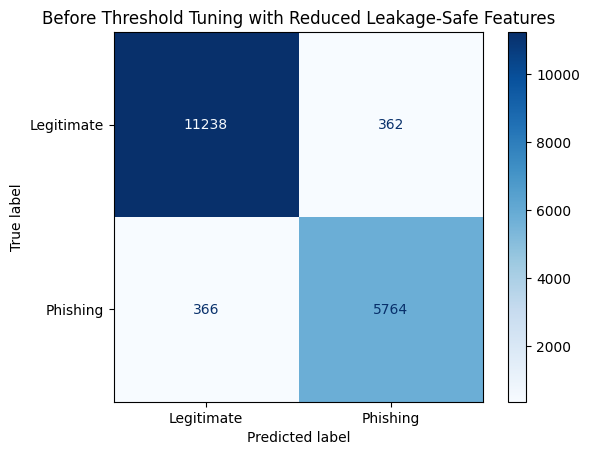

In [61]:
plot_confusion_matrix(y_pred_safe, "Before Threshold Tuning with Reduced Leakage-Safe Features")

In [62]:
plt.savefig("../figures/confusion_matrix_threshold_50_safe.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Label Shuffling Evaluation for Leakage-Safe Reduced Feature Model

Perform a **data leakage sanity check** using label shuffling on the **reduced leakage-safe feature set**:  

1. `evaluate_auc` computes the **AUC scores** over multiple runs where the model is trained on the features but with **randomly shuffled labels**.  
2. Calculate the **mean and standard deviation** of these AUC scores to quantify performance under random labels.  
3. Compare these results with the actual model performance to confirm that the model is **not learning from leaked or spurious information**.  
4. Save the results to a JSON file (`label_shuffling_rf_safe.json`) for documentation and reproducibility using `save_label_shuffling_result`.  

This ensures that the reduced leakage-safe model is **robust and trustworthy**, with predictive power coming from legitimate feature signals rather than accidental leakage.

In [ ]:
aucs = evaluate_auc(rf_safe, X_train_safe, y_train, X_test_safe, y_test)
mean_safe = float(np.mean(aucs))
std_safe = float(np.std(aucs))

0.4889426625696124
0.006470955834158373


In [88]:
print(aucs)
print(mean_safe)
print(std_safe)

[0.4769007917533892, 0.4828848934015863, 0.4940351859143838, 0.4878784665579119, 0.4842416535410924, 0.489725649715925, 0.5020769674298251, 0.49185510772346286, 0.4884355276480846, 0.491392382010463]
0.4889426625696124
0.006470955834158373


In [89]:
save_label_shuffling_result(
    "label_shuffling_rf_safe.json",
    "rf_safe",
    "Leakage-safe reduced-feature model",
    mean_safe,
    std_safe,
    n_runs=10,
    aucs=aucs
)

## Threshold Tuning for Leakage-Safe Reduced Feature Set

Analyze how changing the **decision threshold** affects model performance for the **leakage-safe reduced feature set**.  

- `evaluate_thresholds` computes **precision, recall, and F1-score** across a range of thresholds for the predicted probabilities (`y_proba_safe`).  
- The resulting DataFrame (`threshold_safe_df`) summarizes these metrics for each threshold.  
- `plot_threshold_tuning_curve` visualizes the effect of threshold selection on model performance.  
- This step helps determine the **optimal threshold** after removing features that could lead to data leakage, ensuring both robustness and balanced classification.

In [59]:
threshold_safe_df = evaluate_thresholds(y_proba_safe)
threshold_safe_df

,threshold,precision,recall,f1
0,0.10,0.808051,0.988907,0.889378
1,0.15,0.836497,0.984829,0.904623
2,0.20,0.857245,0.979608,0.914351
3,0.25,0.875550,0.974388,0.922329
4,0.30,0.891657,0.969331,0.928873
5,0.35,0.906984,0.963948,0.934599
6,0.40,0.918323,0.957423,0.937465
7,0.45,0.930511,0.950245,0.940274
8,0.50,0.940610,0.940457,0.940533
9,0.55,0.948616,0.933605,0.941051


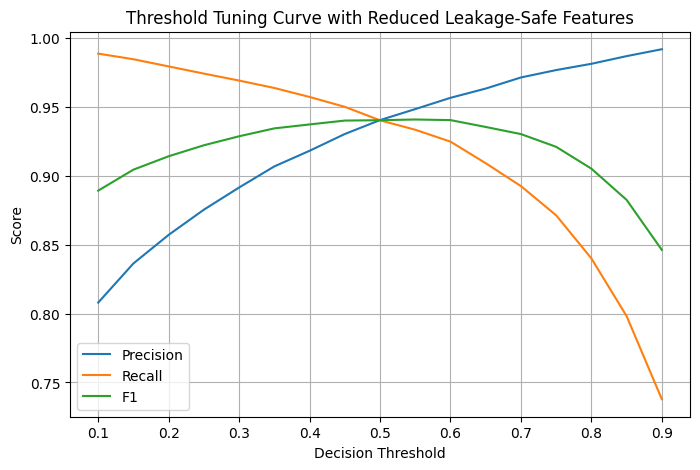

In [64]:
plot_threshold_tuning_curve(threshold_safe_df, "Threshold Tuning Curve with Reduced Leakage-Safe Features")

In [65]:
plt.savefig("../figures/threshold_tuning_curve_safe.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Confusion Matrix After Threshold Tuning (Leakage-Safe Reduced Feature Set)

Visualize the model's predictions **after applying the selected decision threshold** for the leakage-safe reduced feature set.  

- `y_pred_safe` contains predictions converted from probabilities (`y_proba_safe`) using the chosen threshold (`0.4`).  
- Plotting the confusion matrix shows **true positives, false positives, true negatives, and false negatives**.  
- This allows evaluation of how removing potential leakage features and adjusting the threshold affects the model's classification performance.

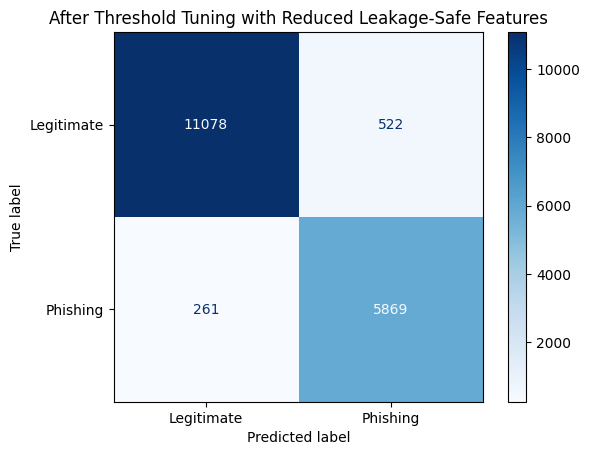

In [66]:
threshold = 0.4

y_pred_safe = (y_proba_safe >= threshold).astype(int)
plot_confusion_matrix(y_pred_safe, "After Threshold Tuning with Reduced Leakage-Safe Features")

In [67]:
plt.savefig("../figures/confusion_matrix_threshold_40_safe.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Sanity Baseline Check

Compare the performance of the Random Forest model against **simple baseline classifiers** to ensure that the model is learning meaningful patterns rather than random noise.  

- Use **DummyClassifier** with different strategies:  
  1. `most_frequent` — always predicts the most common class.  
  2. `stratified` — generates predictions by respecting the class distribution in the training set.  
- Fit each baseline on the training data and evaluate on the test set.  
- The Random Forest model should **significantly outperform these simple baselines**, confirming that it captures informative patterns from the features.

In [100]:
def evaluate_baseline(strategy, X_train, y_train, X_test, y_test):
    dummy = DummyClassifier(strategy=strategy, random_state=42)
    dummy.fit(X_train, y_train)

    y_pred = dummy.predict(X_test)

    y_proba = (
        dummy.predict_proba(X_test)[:, 1]
        if hasattr(dummy, "predict_proba")
        else None
    )

    plot_confusion_matrix(y_pred)

    print("\nMetrics:")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

    if y_proba is not None:
        print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

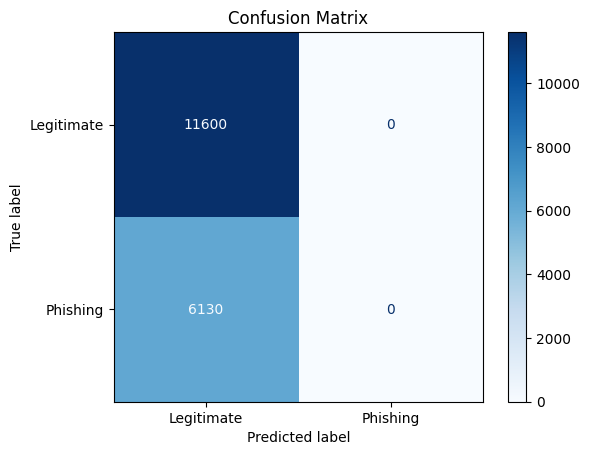


Metrics:
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
ROC-AUC:   0.5000


In [101]:
evaluate_baseline(
    "most_frequent",
    X_train_safe,
    y_train,
    X_test_safe,
    y_test
)

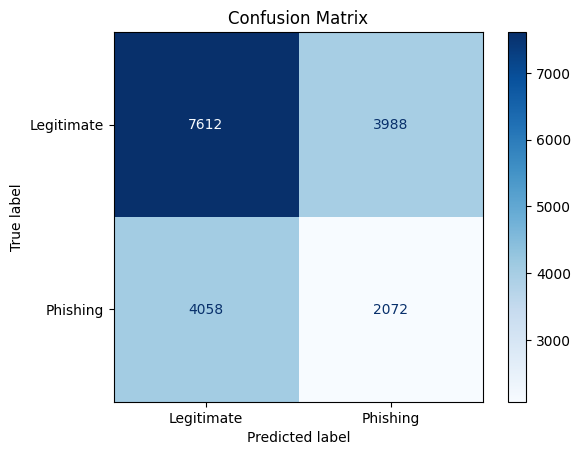


Metrics:
Precision: 0.3419
Recall:    0.3380
F1 Score:  0.3400
ROC-AUC:   0.4971


In [102]:
evaluate_baseline(
    "stratified",
    X_train_safe,
    y_train,
    X_test_safe,
    y_test
)

## Save Final Model Pipeline with Metadata

After completing evaluation and analysis, save the **final trained Random Forest pipeline** along with relevant **metadata** for future use or deployment.  

- The metadata includes:
  - Version information
  - Training timestamp
  - Random state for reproducibility
  - Feature names
  - Hyperparameters of the trained model
  - Class weight used
  - Decision threshold
  - Scoring metric
  - Cross-validation strategy
  - Additional notes (e.g., feature types)

- Use `joblib.dump` to store both the pipeline and metadata as a single file.  
- Load the pipeline later using `joblib.load` to confirm that both the model and metadata are intact and ready for inference or deployment.

In [112]:
rf_pipeline = Pipeline([
    ("model", rf_safe)
])

params = rf_pipeline.named_steps["model"].get_params()

metadata = {
    "version": "v1.0",
    "trained_on": datetime.datetime.now().isoformat(),
    "random_state": params.get("random_state"),
    "features": X_train_safe.columns.tolist(),
    "hyperparameters": params,
    "class_weight": params.get("class_weight"),
    "threshold": 0.4,
    "scoring": "f1",
    "cv_strategy": "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)",
    "notes": "Reduced leakage-safe model including both URL and DNS features"
}

dump(
    {
        "pipeline": rf_pipeline,
        "metadata": metadata,
    },
    "../models/phishing_rf_pipeline_v1.joblib"
)

['../models/phishing_rf_pipeline_v1.joblib']

In [27]:
bundle = load("../models/phishing_rf_pipeline_v1.joblib")
best_pipeline = bundle["pipeline"]
metadata = bundle["metadata"]